# KAN-CDSCO2004U  Machine Learning and Deep Learning

## Lab 8: Stochastic Gradient Descent — ✅ Solution
**Estimated time: 1 hour**

### Learning Objectives
By the end of this exercise, you will be able to:
- Perform **Simple Linear Regression** from scratch
- Build a **Stochastic Gradient Descent** from scratch
- Apply it to the **California housing dataset**

**How to work through this notebook:**
- 🏃 **RUN** cells = Just execute the code to see the output
- ✏️ **TODO** cells = Write your own code or answer questions
- 📖 **READ** cells = Explanations to help you understand the concepts
- 💡 **EXPLANATION** cells = detailed code explanations

## <center> Lecture-08 "Stochastic Gradient Descent"

📖 **READ**

# Build Stochastic Gradient Descent, Gradient Descent From Linear Regression on California housing dataset [From scratch]

🏃 **RUN**

- Will use California housing dataset. Data is quite sparse, but we can still observe some linearity.
- Perform a linear regression to predict apartment prices based on the median income in the block. 
- We will start from the simple linear regression and gradually finish with Stochastic Gradient Descent.

In [1]:
# Import Libraries
# Authors: Francesco Esposito (fe.digi@cbs.dk), Luca Gudi (lgg.digi@cbs.dk)
# code src: Arseny Turin
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

In [2]:
# Import California Housing Dataset from SkLearn and Store it in a Variable
from sklearn.datasets import fetch_california_housing
housing_data = fetch_california_housing()

### 💡 Detailed Code Explanation
| Syntax/Method | Detailed Explanation/Purpose |
|---|---|
| `fetch_california_housing()` | A built-in scikit-learn function that downloads the California housing dataset. |
| `housing_data = ...` | `housing_data` acts as a variable storing the downloaded dataset object, which contains the data matrix andfeature names. |


In [3]:
# Build Features and Target Dataframe 
Features = pd.DataFrame(housing_data.data, columns=housing_data.feature_names)
Target = pd.DataFrame(housing_data.target, columns=['Target'])

### 💡 Detailed Code Explanation
| Syntax/Method | Detailed Explanation/Purpose |
|---|---|
| `housing_data.data` | Accesses the 'data' attribute of the dataset, representing the input features. |
| `housing_data.target` | Accesses the target variable (the values we want to predict). |
| `['Target']` | A Python list containing a single string 'Target', used to explicitly name the single column in the Target dataframe. |


In [4]:
# Build One Joined Dataframe and Look at the Correlation Values
df = Features.join(Target)
df.corr()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
Target,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


✏️ **TO DO**

## Preprocessing: Removing Outliers

- `Target` and `MedInc` has outliers, because 75% of the data has price less than 2.65, but maximum price go as high as 5. 
- Remove extremely expensive houses.

In [5]:
# Get an Overview of the columns 'MedInc' (Median Income) and 'Target'
df[['MedInc', 'Target']].describe()[1:]

,MedInc,Target
mean,3.870671,2.068558
std,1.899822,1.153956
min,0.499900,0.149990
25%,2.563400,1.196000
50%,3.534800,1.797000
75%,4.743250,2.647250
max,15.000100,5.000010


In [6]:
# Remove the extremely expensive houses
df = df[df.Target < 3.5]
df = df[df.MedInc < 8]

### 💡 Detailed Code Explanation
| Syntax/Method | Detailed Explanation/Purpose |
|---|---|
| `df.Target < 3.5` | Creates a boolean mask (a list of True/False values). For each row, it checks if the 'Target' value is less than 3.5. |
| `df[...]` | We pass the True/False mask back into the DataFrame using brackets. This filters the DataFrame, keeping only the rows where the mask is True. |
| `.reset_index()` | After filtering rows out, the old row indices (e.g. 0, 1, 3, 7...) are kept intact. `reset_index` resets them to a clean 0, 1, 2, 3 sequence. |
| `drop=True` | A parameter for `reset_index`. If `True`, it drops the old index entirely. If `False` (the default), it inserts the old index as a new column in the DataFrame, which we usually don't want. |


---

## Stage-01 -- Develop Simple Linear Regression from Scratch

📖 **READ**

We start with a basic Single-variable Linear Regression model.



Simple linear regression can be described by only two parameters: slope `m` and intercept `b`. Lets take a look at the formulas below:

✏️ **TODO**

### 1. Slope Calculation

The slope \( m \) is calculated using the formula:

$m = \frac{\overline{X} \overline{Y} - \overline{XY}}{\overline{X^2} - (\overline{X})^2}$

Where $ \bar{X} $ is the mean of $ X $, and $ \bar{y} $ is the mean of $ y $

### 2. Intercept Calculation

The intercept \( b \) is calculated as:

$b = \overline{y} - m \times \overline{X}$

### 3. Predictions

Predicted \( y \) values are found using:

$y_{\text{pred}} = mX + b$

### 4. Mean Squared Error (MSE)

MSE measures the goodness of fit of the line:

1. Error calculation: $\text{error} = y - y_{\text{pred}}$
2. Squared error: $\text{squared\_error} = (\text{error})^2$
3. Mean Squared Error: $MSE = \frac{\sum (\text{squared\_error})}{\text{total number of data points}}$

In [7]:
# [TODO] use MedInc` and `Target` variable to build X and y
X = df.MedInc
y = df.Target

In [8]:
# Step 1: Calculate slope and intercept
m = ((np.mean(X) * np.mean(y) - np.mean(X*y)) / ((np.mean(X)**2) - np.mean(X**2)))
b = np.mean(y) - m * np.mean(X)

# Step 2: Calculate predicted y values using the linear regression equation
y_pred = m * X + b

# Step 3: Calculate MSE from scratch and print it
error = y - y_pred
squared_error = error ** 2
mse = sum(squared_error) / len(squared_error)
print("MSE:", mse)


MSE: 0.34320521502255913


### 💡 Detailed Code Explanation
| Syntax/Method | Detailed Explanation/Purpose |
|---|---|
| `error = ...` | Calculates the residuals (difference between true y and predicted y). |
| `** 2` | The Python operator for exponentiation. `** 2` squares the values. We square errors so that negative errors and positive errors don't cancel each other out when we sum them. |
| `sum(...)` | Sums all the values in an array/list. |
| `len(...)` | Returns the total number of items in an array. By dividing the sum of squared errors by the length, we get the 'Mean' Squared Error. |


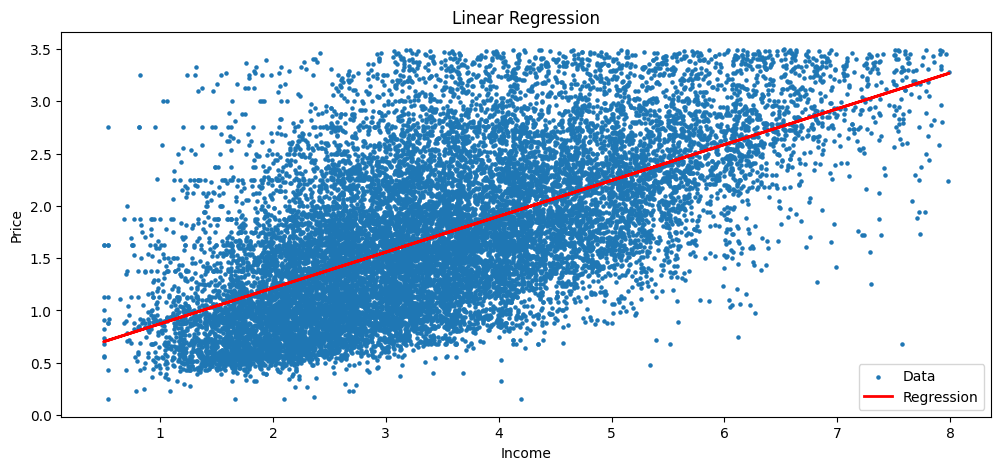

In [9]:
# Plot the results
plt.figure(figsize=(12,5))
plt.scatter(X, y, label='Data', s=5)
plt.plot(X, y_pred, 'r', lw=2, label='Regression')
plt.title("Linear Regression")
plt.xlabel('Income')
plt.ylabel('Price')
plt.legend()
plt.show()

---

## Stage-02 -- Stochastic Gradient Descent from Scratch

📖 **READ**

Now we will implement SGD.

✏️ **TODO**

When using gradient descent we want to update our `m` and  `b` parameters by using the formula of partial derivative of the loss function. The derivative respect to  `m`  is:
$$\frac{\partial L}{\partial m}=\frac{-2}{n}\sum^n_{i=0}x_i(y_i-\bar{y_i})$$
And the derivative with respect to  `b`:
$$\frac{\partial L}{\partial b}=\frac{-2}{n}\sum^n_{i=0}(y_i-\bar{y_i})$$

The partial derivatives of the loss function with respect to `m` and `b` give us the gradient, which points in the direction of the steepest increase of the loss function. By moving in the opposite direction (i.e., descending), we aim to reduce the loss. Specifically, the partial derivative with respect to `m` indicates how the loss changes with a small change in `m`, and similarly for `b`. The learning rate determines the size of the steps we take along this gradient towards the minimum - this is the reason why we multiply the derivative with the learning rate in the code. If the learning rate is too large, we might overshoot the minimum; if it's too small, the convergence might be very slow.

In [10]:
# Set the parameters lr=0.01, epoch=100, m = 0.2 and b = 0.2

# Set the m, b parameters
m_gd, b_gd = 0.2, 0.2

# Build a list to store learning process
log_gd, mse_gd = [], []

N = len(X)

for epoch in range(100):                
    error = y - (m_gd*X + b_gd)
    m_gd -= 0.01 * -2 * X.dot(error).sum() / N
    b_gd -= 0.01 * -2 * error.sum() / N
    
    log_gd.append((m_gd, b_gd))
    mse_gd.append(mean_squared_error(y, m_gd*X + b_gd))

y_pred_gd = m_gd * X + b_gd

| Component                     | Explanation                                                                            |
| ----------------------------- | -------------------------------------------------------------------------------------- |
| `m_gd`, `b_gd`                | Initial values for the slope and intercept of the regression line.                     |
| `epoch` loop                  | Each iteration updates the parameters using the full dataset.                          |
| `error = y - (m_gd*X + b_gd)` | Computes the difference between the true target values and the model predictions.      |
| Gradient update               | The parameters are updated using the gradient of the Mean Squared Error loss function. |
| `log_gd`                      | Stores the parameter values `(m, b)` at each iteration to track the learning process.  |
| `mse_gd`                      | Stores the Mean Squared Error at each iteration to observe convergence.                |
| `y_pred_gd`                   | Final predictions produced by the trained model.                                       |


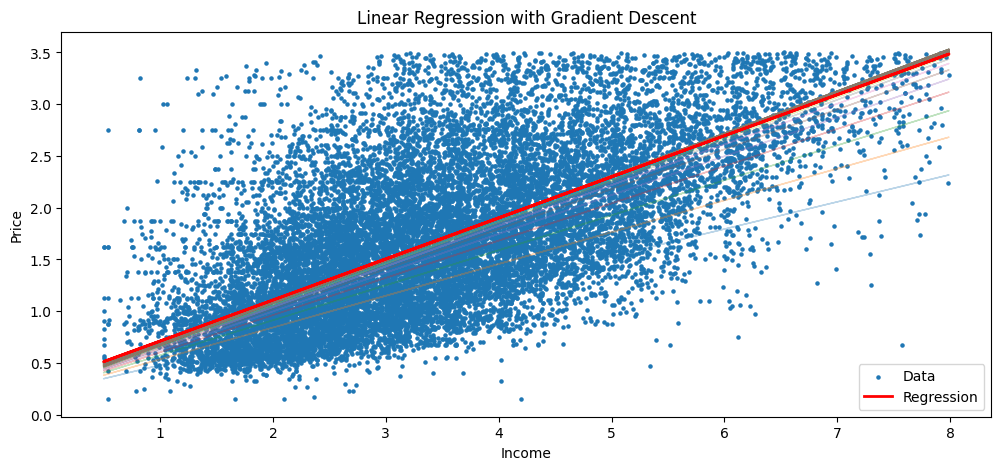

GD MSE: 0.3493097403876614


In [11]:
# Plot gradient descent results
plt.figure(figsize=(12,5))
plt.scatter(X, y, label='Data', s=5)
for i in range(len(log_gd)):
    plt.plot(X, log_gd[i][0]*X + log_gd[i][1], lw=1, alpha=0.3)
plt.plot(X, y_pred_gd, 'r', lw=2, label='Regression')
plt.title("Linear Regression with Gradient Descent")
plt.xlabel('Income')
plt.ylabel('Price')
plt.legend()
plt.show()
print("GD MSE:", mean_squared_error(y, y_pred_gd))

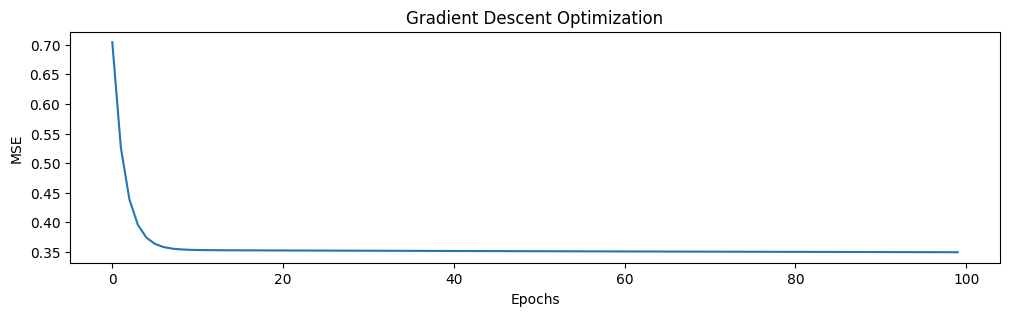

In [12]:
# Plot MSE curve
plt.figure(figsize=(12,3))
plt.plot(range(len(mse_gd)), mse_gd)
plt.title('Gradient Descent Optimization')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.show()


## Stage-03 -- Stochastic Gradient Descent

✏️ **TODO**

- SGD works almost the same as Gradient Descent, it picks only one sample to update `m` and `b` parameters
- Make change to sample size (`batch_size`), sometimes its better to use more than one sample at a time.

In [13]:
# Set the parameters lr=0.01, epoch=100 and batch size=2,  also set m = 0.5 together with b = 0.5

# Convert X and y to numpy arrays
X_np, y_np = np.array(X), np.array(y)

# Set the m, b parameters
m_sgd, b_sgd = 0.5, 0.5

# Build a list to store learning process
log_sgd, mse_sgd = [], []

np.random.seed(42)

for epoch in range(100):
    # Randomly sampling
    idx = np.random.randint(0, len(X_np), 2)
    X_batch, y_batch = X_np[idx], y_np[idx]
    N = len(X_batch)
    
    # Compute error and update parameters
    error = y_batch - (m_sgd * X_batch + b_sgd)
    m_sgd -= 0.01 * (-2 * X_batch.dot(error).sum() / N)
    b_sgd -= 0.01 * (-2 * error.sum() / N)
    
    log_sgd.append((m_sgd, b_sgd))
    mse_sgd.append(mean_squared_error(y, m_sgd*X + b_sgd))

y_pred_sgd = m_sgd * X + b_sgd

| Component                | Explanation                                                                        |
| ------------------------ | ---------------------------------------------------------------------------------- |
| `X_np, y_np`             | Convert the data to NumPy arrays to enable efficient indexing for random sampling. |
| `m_sgd`, `b_sgd`         | Initial slope and intercept of the regression model.                               |
| `np.random.seed(42)`     | Ensures reproducibility of the random sampling process.                            |
| `np.random.randint(...)` | Randomly selects indices to create a mini-batch of size 2.                         |
| `X_batch`, `y_batch`     | Subset of the dataset used to compute the gradient in each iteration.              |
| Gradient update          | Parameters are updated using only the sampled batch.                               |
| `log_sgd`                | Stores parameter values during training.                                           |
| `mse_sgd`                | Tracks the model error over time using the full dataset.                           |


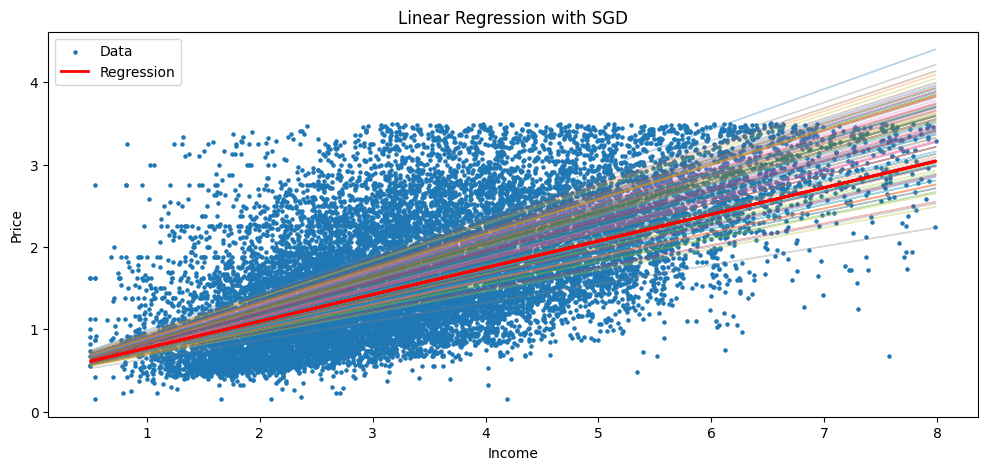

SGD MSE: 0.3648500017361


In [14]:
# Plot SGD results
plt.figure(figsize=(12,5))
plt.scatter(X, y, label='Data', s=5)
for i in range(len(log_sgd)):
    plt.plot(X, log_sgd[i][0]*X + log_sgd[i][1], lw=1, alpha=0.3)
plt.plot(X, y_pred_sgd, 'r', lw=2, label='Regression')
plt.title("Linear Regression with SGD")
plt.xlabel('Income')
plt.ylabel('Price')
plt.legend()
plt.show()
print("SGD MSE:", mean_squared_error(y, y_pred_sgd))

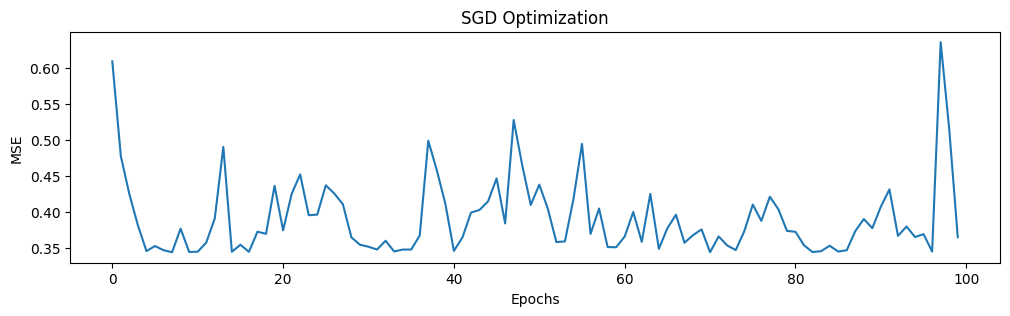

In [15]:
# Plot MSE curve of SGD
plt.figure(figsize=(12,3))
plt.plot(range(len(mse_sgd)), mse_sgd)
plt.title('SGD Optimization')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.show()

## Summary

| Concept                               | Role in the Notebook                     | Key Idea                                                                                                                                       |
| ------------------------------------- | ---------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------- |
| **California Housing Dataset**        | Dataset used for the regression example  | Provides real-world data where the goal is to predict house values based on socioeconomic features.                                            |
| **Linear Regression Model**           | Predictive model used in the exercise    | Assumes a linear relationship between the input feature (X) and the target (y), defined by the parameters **slope (m)** and **intercept (b)**. |
| **Model Parameters (m, b)**           | Variables learned during training        | These parameters define the regression line and are updated iteratively during optimization.                                                   |
| **Prediction Function**               | Model output computation                 | Predictions are computed as ( y_{pred} = mX + b ).                                                                                             |
| **Mean Squared Error (MSE)**          | Loss function used to evaluate the model | Measures the average squared difference between predicted and true values. Lower values indicate better model performance.                     |
| **Batch Gradient Descent (GD)**       | Optimization algorithm                   | Updates model parameters using the **entire dataset** at each iteration, producing stable and smooth learning updates.                         |
| **Stochastic Gradient Descent (SGD)** | Alternative optimization algorithm       | Updates parameters using **small randomly sampled batches**, leading to noisier but often faster learning.                                     |
| **Training Process (Epochs)**         | Iterative learning procedure             | Each epoch updates the model parameters based on the gradient of the loss function.                                                            |
| **Loss Tracking**                     | Monitoring training progress             | The MSE values stored during training allow visualization of how the model improves over time.                                                 |
